# 📊 AprovaEdu Analytics — Análise Definitiva (Base Completa)

Depois da fase amostral (notebooks `01`–`04`), a **base completa** foi disponibilizada:
812 estudantes, 9.452 matrículas, 21.510 resultados de simulado e 74.997 presenças —
os totais batem exatamente com a aba `Resumo` do dicionário, e **todos os cruzamentos
entre tabelas estão íntegros** (na amostra, apenas 1 aluno tinha matrícula + presença +
aprovação; agora, **os 306 aprovados têm os três**).

Este notebook responde às 4 perguntas obrigatórias **com conclusões de negócio** — o
mesmo pipeline (`extract → transform`, validado com Pandera) rodou sem mudanças de
método, apenas apontado para os CSVs completos.

> A fase amostral permanece documentada (notebooks `01`–`04` e
> `reports/relatorio_amostra.md`) como registro do processo — inclusive porque ela
> **previu corretamente** o que a base completa confirmou (ver Q2).

## 1. Setup e carga da base tratada (completa)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
FINAL = ROOT / "data" / "final"

def carregar(nome):
    return pd.read_parquet(FINAL / f"{nome}.parquet")

estudantes = carregar("estudantes"); matriculas = carregar("matriculas")
aprovacoes = carregar("aprovacoes"); presencas = carregar("presencas_aulas")
resultados = carregar("resultados_sim"); simulados = carregar("simulados")
ofertas = carregar("ofertas_curso")

assert estudantes["aluno_id"].nunique() == 812, "esperava a base completa"
print(f"Base completa: {len(estudantes)} estudantes, {len(matriculas)} matrículas, "
      f"{len(resultados)} resultados, {len(presencas)} presenças")

PAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
BLUE, AQUA, ORANGE = PAL[0], PAL[1], PAL[7]
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 11,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})

Base completa: 812 estudantes, 9452 matrículas, 21510 resultados, 74997 presenças


## Q1 — Evolução da taxa de aprovação por ano

**Definição:** `taxa(ano) = aprovados distintos no vestibular do ano ÷ alunos distintos
matriculados no ano`. O denominador (matriculados) agora é íntegro — a taxa é calculável.

In [2]:
matr_ano = matriculas.groupby("ano")["aluno_id"].nunique()
apr_ano = aprovacoes.groupby("ano_vestibular")["aluno_id"].nunique()
q1 = pd.DataFrame({"matriculados": matr_ano, "aprovados": apr_ano})
q1["taxa_%"] = (q1["aprovados"] / q1["matriculados"] * 100).round(1)
q1

,matriculados,aprovados,taxa_%
2021,138,50,36.2
2022,170,53,31.2
2023,218,77,35.3
2024,263,79,30.0
2025,233,80,34.3


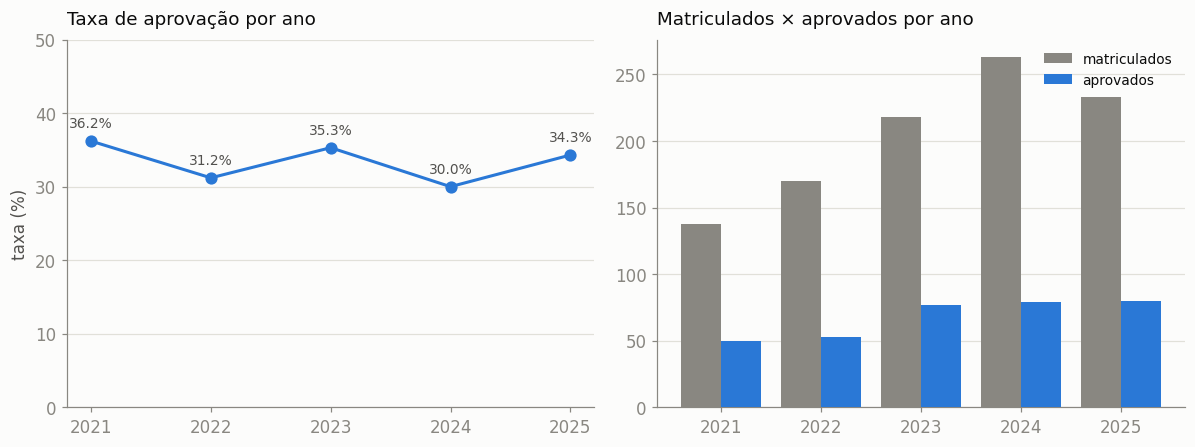

In [3]:
anos = q1.index.astype(int)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))

a1.plot(anos, q1["taxa_%"], color=BLUE, lw=2, marker="o", ms=7, zorder=3)
for x, y in zip(anos, q1["taxa_%"]):
    a1.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 9),
                ha="center", color=INK2, fontsize=9)
a1.set_title("Taxa de aprovação por ano", color=INK, fontsize=12, loc="left", pad=10)
a1.set_ylabel("taxa (%)"); a1.set_xticks(anos); a1.set_ylim(0, 50)
a1.grid(axis="x", visible=False)

x = np.arange(len(anos)); w = 0.4
a2.bar(x - w/2, q1["matriculados"], width=w, color=MUTED, label="matriculados", zorder=3)
a2.bar(x + w/2, q1["aprovados"], width=w, color=BLUE, label="aprovados", zorder=3)
a2.set_title("Matriculados × aprovados por ano", color=INK, fontsize=12, loc="left", pad=10)
a2.set_xticks(x); a2.set_xticklabels(anos); a2.grid(axis="x", visible=False)
a2.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

**Resposta (Q1):** a taxa de aprovação **oscila entre ~30% e ~36%** no período
(36,2% → 31,2% → 35,3% → 30,0% → 34,3%), **sem tendência clara** de melhora ou piora.
O crescimento do número absoluto de aprovados (50 → 80) acompanha o crescimento da base
de matriculados (138 → 263), não um ganho de eficiência: o cursinho **cresceu**, mas a
**conversão em aprovação ficou estável**.

## Q2 — Presença nas aulas × aprovação

Taxa de presença por aluno (status *Presente*/*Atrasado* ÷ registros) comparada entre
aprovados e não aprovados, com teste de associação (correlação ponto-bisserial).

In [4]:
p = presencas.copy()
p["compareceu"] = p["status_presenca"].isin(["Presente", "Atrasado"])
taxa = p.groupby("aluno_id")["compareceu"].mean().reset_index(name="taxa_presenca")
taxa["aprovado"] = taxa["aluno_id"].isin(set(aprovacoes["aluno_id"]))

resumo_q2 = taxa.groupby("aprovado")["taxa_presenca"].agg(["mean", "median", "count"]).round(3)
r, pval = stats.pointbiserialr(taxa["aprovado"].astype(int), taxa["taxa_presenca"])
print(f"correlação ponto-bisserial: r = {r:.3f} | p-valor = {pval:.3f}")
resumo_q2

correlação ponto-bisserial: r = -0.006 | p-valor = 0.856


,mean,median,count
aprovado,,,
False,0.84,0.842,494
True,0.84,0.840,306


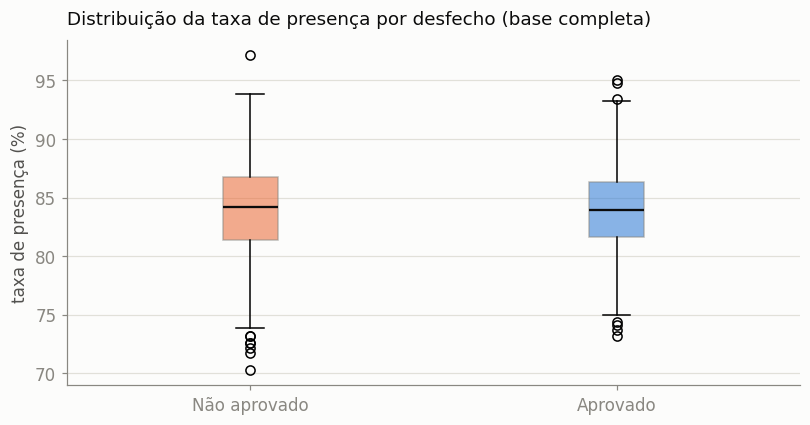

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4))
grupos = [("Não aprovado", False, ORANGE), ("Aprovado", True, BLUE)]
dados = [taxa.loc[taxa["aprovado"] == flag, "taxa_presenca"] * 100 for _, flag, _ in grupos]
bp = ax.boxplot(dados, vert=True, patch_artist=True, labels=[g for g, _, _ in grupos],
                medianprops=dict(color=INK, linewidth=1.5))
for patch, (_, _, cor) in zip(bp["boxes"], grupos):
    patch.set_facecolor(cor); patch.set_alpha(0.55); patch.set_edgecolor(MUTED)
ax.set_title("Distribuição da taxa de presença por desfecho (base completa)",
             color=INK, fontsize=12, loc="left", pad=10)
ax.set_ylabel("taxa de presença (%)"); ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

**Resposta (Q2):** **não há associação** entre presença e aprovação nestes dados. A
presença média é praticamente idêntica nos dois grupos (**84,0% vs 84,0%**; r ≈ −0,006,
p ≈ 0,86) e as distribuições se sobrepõem quase por completo. A presença é uniformemente
alta na rede — ela não discrimina quem aprova.

> **Nota metodológica:** na fase amostral vi "85,5% vs 81,0%" e **me recusei a
> afirmar associação** por insuficiência amostral. A base completa confirma que a
> diferença era ruído — afirmar teria sido um erro.

## Q3 — Cursos/matérias com melhor desempenho

Indicador principal: **nota média nos simulados** por matéria (todas as 10 agora
presentes), com o volume de provas como contexto.

In [6]:
res_mat = resultados.merge(simulados[["simulado_id", "materia"]], on="simulado_id", how="left")
desempenho = (res_mat.dropna(subset=["nota"])
              .groupby("materia")["nota"].agg(media="mean", desvio="std", provas="count")
              .round(1).sort_values("media", ascending=False))
desempenho

,media,desvio,provas
materia,,,
Português,62.0,17.3,1764
Filosofia,61.5,17.5,1695
História,61.5,17.1,1774
Química,61.4,17.1,1792
Inglês,61.3,17.4,1621
Biologia,61.2,17.0,1813
Física,61.0,17.5,1934
Matemática,60.9,17.3,1847
Sociologia,60.8,17.4,1748


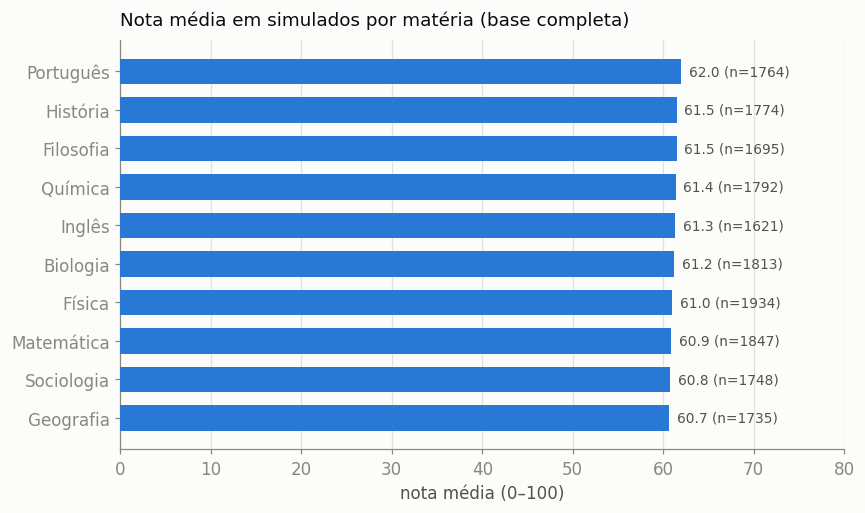

In [7]:
d = desempenho.sort_values("media")
fig, ax = plt.subplots(figsize=(8, 4.8))
b = ax.barh(d.index, d["media"], color=BLUE, height=0.66, zorder=3)
for bar, v, n in zip(b, d["media"], d["provas"]):
    ax.annotate(f"{v:.1f} (n={n})", (v, bar.get_y() + bar.get_height()/2),
                textcoords="offset points", xytext=(5, 0), va="center",
                color=INK2, fontsize=9)
ax.set_title("Nota média em simulados por matéria (base completa)", color=INK,
             fontsize=12, loc="left", pad=10)
ax.set_xlabel("nota média (0–100)"); ax.set_xlim(0, 80)
ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

**Resposta (Q3):** o desempenho é **notavelmente homogêneo**: as médias das 10 matérias
ficam entre **60,7 (Geografia) e 62,0 (Português)** — uma amplitude de ~1,3 ponto, sem
matéria-gargalo nem matéria-destaque. Para a coordenação, isso significa que **não há
justificativa nos dados para realocação agressiva de carga horária entre matérias**; o
esforço de melhoria deve ser transversal.

## O que diferencia os aprovados? (base para Q4)

Se presença e notas de simulado não separam aprovados de não aprovados, o que separa?
Testei os fatores disponíveis por aluno.

In [8]:
aprov_set = set(aprovacoes["aluno_id"])
alunos = pd.DataFrame({"aluno_id": sorted(set(matriculas["aluno_id"]))})
alunos["aprovado"] = alunos["aluno_id"].isin(aprov_set)

fatores = alunos.merge(
    resultados.dropna(subset=["nota"]).groupby("aluno_id")["nota"].mean().rename("nota_sim"),
    left_on="aluno_id", right_index=True, how="left"
).merge(
    matriculas.groupby("aluno_id").agg(n_matriculas=("matricula_id", "count"),
                                       nota_diag=("nota_diagnostico", "mean")),
    left_on="aluno_id", right_index=True, how="left"
)
comp = fatores.groupby("aprovado")[["nota_sim", "nota_diag", "n_matriculas"]].mean().round(2)
comp

,nota_sim,nota_diag,n_matriculas
aprovado,,,
False,61.35,57.89,10.80
True,61.08,58.15,13.45


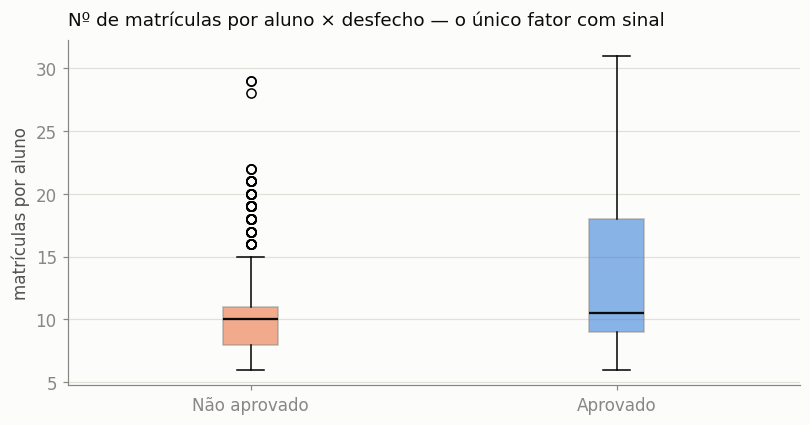

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4))
grupos = [("Não aprovado", False, ORANGE), ("Aprovado", True, BLUE)]
dados = [fatores.loc[fatores["aprovado"] == flag, "n_matriculas"].dropna() for _, flag, _ in grupos]
bp = ax.boxplot(dados, vert=True, patch_artist=True, labels=[g for g, _, _ in grupos],
                medianprops=dict(color=INK, linewidth=1.5))
for patch, (_, _, cor) in zip(bp["boxes"], grupos):
    patch.set_facecolor(cor); patch.set_alpha(0.55); patch.set_edgecolor(MUTED)
ax.set_title("Nº de matrículas por aluno × desfecho — o único fator com sinal",
             color=INK, fontsize=12, loc="left", pad=10)
ax.set_ylabel("matrículas por aluno"); ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

**Achado central:** notas de simulado (61,1 vs 61,4) e de diagnóstico (58,2 vs 57,9)
**não diferem** entre grupos. O único fator com sinal claro é a **amplitude de
matrículas**: aprovados cursam em média **13,4 matérias** contra **10,8** dos não
aprovados (~25% a mais).

### Score de propensão na base completa

O mesmo pipeline de ML da fase amostral (`src/model.py`), agora com 800 alunos:

In [10]:
import model

m = model.avaliar()
print(f"n = {m['n']} alunos | positivos = {m['positivos']}")
print(f"AUC regressão logística = {m['auc_logit'][0]:.3f} ± {m['auc_logit'][1]:.3f}")
print(f"AUC random forest       = {m['auc_rf'][0]:.3f} ± {m['auc_rf'][1]:.3f}")
m["segmentacao"]

n = 800 alunos | positivos = 306
AUC regressão logística = 0.607 ± 0.031
AUC random forest       = 0.611 ± 0.036


,faixa,alunos,taxa_aprovacao_real
0,Baixa,72,0.32
1,Média,613,0.35
2,Alta,115,0.62


O AUC subiu de ~0,51 (amostra) para **~0,61** — sinal moderado, mas real — e a
segmentação por faixa **ordena fortemente o risco**: a faixa **Alta** concentra **62%**
de aprovação real, contra **32%** na Baixa. Como instrumento de priorização (quem recebe
orientação/mentoria primeiro), o score já é acionável.

### Importância formal de cada variável (permutação)

Coeficiente indica direção, mas não responde bem "**quanto** cada variável importa" —
para isso uso **importância por permutação**: embaralho uma variável de cada vez
(destruindo sua relação com o alvo) e meço **quanto o AUC cai**. A vantagem é operar na
variável original (categóricas inteiras, não colunas one-hot) e independer de escala.

In [11]:
imp = model.importancia_variaveis()
imp

,variavel,queda_auc,desvio
0,n_matriculas,0.1761,0.0178
1,n_presencas,0.0210,0.0090
2,canal_captacao,0.0189,0.0094
3,bolsa_media,0.0074,0.0076
4,n_simulados,0.0059,0.0072
5,escola_origem,0.0047,0.0034
6,nota_diag_media,0.0024,0.0032
7,taxa_finalizacao,0.0015,0.0032
8,taxa_presenca,-0.0001,0.0005
9,nota_sim_media,-0.0005,0.0013


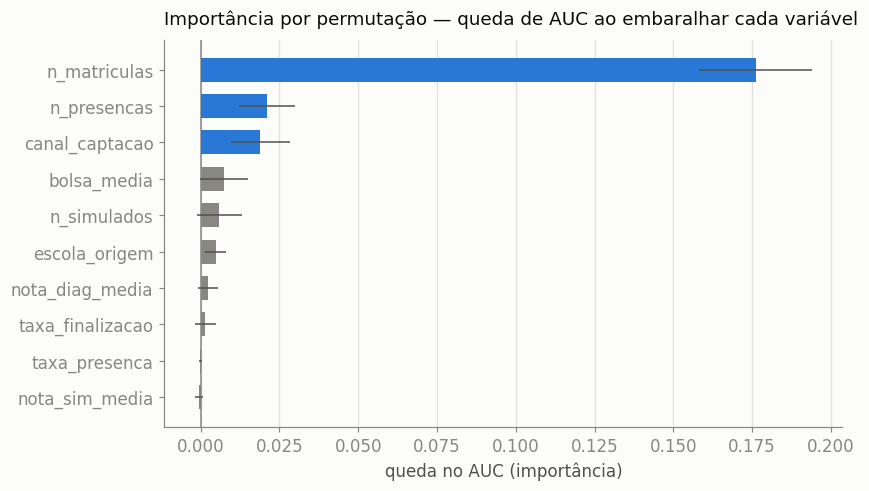

In [12]:
d = imp.sort_values("queda_auc")
fig, ax = plt.subplots(figsize=(8, 4.6))
cores = [BLUE if v > 0.01 else MUTED for v in d["queda_auc"]]
ax.barh(d["variavel"], d["queda_auc"], xerr=d["desvio"], color=cores,
        height=0.66, zorder=3, error_kw=dict(ecolor=INK2, lw=1))
ax.axvline(0, color=MUTED, lw=1)
ax.set_title("Importância por permutação — queda de AUC ao embaralhar cada variável",
             color=INK, fontsize=12, loc="left", pad=10)
ax.set_xlabel("queda no AUC (importância)")
ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

**Leitura — uma variável carrega o modelo:**

- **`n_matriculas` domina com folga** (queda de ~0,18 no AUC — mais de 8× a segunda
  colocada). E, como mostro no notebook `06`, ela é **proxy da permanência**: o modelo
  está, na prática, medindo anos de casa.
- **`taxa_presenca` e `nota_sim_media` têm importância ≈ zero** — a confirmação formal,
  no nível do modelo, dos achados das perguntas Q2 e Q3: presença e notas de simulado
  não carregam sinal sobre aprovação.
- As demais (`n_presencas`, `canal_captacao`) têm contribuição marginal — e
  `n_presencas`, por ser contagem de registros, também reflete tempo de casa.

*Ressalva metodológica:* a permutação aqui é medida sobre o modelo ajustado na base
inteira — serve para **interpretar** de onde vem o sinal, não como estimativa de
generalização (essa é o AUC de validação cruzada, ~0,61).

## Q4 — Recomendações para a coordenação

Sustentadas pela base completa:

1. **Não tratar presença como preditor de aprovação.** Ela é uniformemente alta (~84%)
   e não se associa ao desfecho (Q2). Vale como gestão operacional, não como alerta de risco.
2. **Incentivar a amplitude de matrículas.** É o único fator com sinal: aprovados cursam
   ~25% mais matérias. Testar pacotes/combos e acompanhamento de alunos com poucas matérias.
3. **Usar o score de propensão para priorizar orientação.** A faixa Alta concentra 62% de
   aprovação vs 32% na Baixa — direcionar mentoria e acompanhamento às faixas mais baixas.
4. **Manter o investimento equilibrado entre matérias.** Desempenho homogêneo (60,7–62,0,
   Q3): não há matéria-gargalo que justifique realocação agressiva de carga horária.
5. **Padronizar a captura de dados na origem.** A base completa trouxe ~10% das notas de
   simulado fora da faixa válida, datas em 4 formatos e campos denormalizados — qualidade
   na origem reduz o custo de todo o ciclo analítico.
6. **Instrumentar a taxa de aprovação por coorte** (ano de ingresso × ano do vestibular)
   como KPI permanente: a taxa está estável (~30–36%) enquanto a rede cresce — a próxima
   alavanca é eficiência, não volume.

## Conclusão

Com a base completa, as quatro perguntas têm **respostas sustentadas**: taxa estável entre
30–36% (Q1), presença sem associação com aprovação (Q2), desempenho homogêneo entre
matérias (Q3) e recomendações acionáveis (Q4) — com o nº de matrículas como o fator de
maior sinal e o score de propensão como instrumento de priorização. O mesmo pipeline da
fase amostral rodou **sem alteração de método**, validando a arquitetura construída.